# 01 — Exploratory Data Analysis

Scope: top 150 SKUs (by total units) in category **FOODS_3**, stores **CA_1** and **TX_1**, 2013-01-01 through end of data (2016-05-22). Data source: `data/processed/modeling_table.parquet`, built by `src/data_prep.py`.

This notebook characterizes the demand patterns that the forecasting models in `02_modeling.ipynb` need to capture: seasonality, event effects, SKU-level volatility, intermittency, and price sensitivity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_parquet("../data/processed/modeling_table.parquet")
print(f"{len(df):,} rows | {df['date'].min().date()} to {df['date'].max().date()} | "
      f"{df['item_id'].nunique()} items x {df['store_id'].nunique()} stores")
df.head()

371,400 rows | 2013-01-01 to 2016-05-22 | 150 items x 2 stores


,item_id,store_id,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap,is_event,sell_price,price_change_flag
0,FOODS_3_007,CA_1,17,2013-01-01,11249,Tuesday,4,1,2013,NewYear,National,NaN,NaN,1,True,0.2,False
1,FOODS_3_007,CA_1,4,2013-01-02,11249,Wednesday,5,1,2013,NaN,NaN,NaN,NaN,1,False,0.2,False
2,FOODS_3_007,CA_1,4,2013-01-03,11249,Thursday,6,1,2013,NaN,NaN,NaN,NaN,1,False,0.2,False
3,FOODS_3_007,CA_1,0,2013-01-04,11249,Friday,7,1,2013,NaN,NaN,NaN,NaN,1,False,0.2,False
4,FOODS_3_007,CA_1,16,2013-01-05,11250,Saturday,1,1,2013,NaN,NaN,NaN,NaN,1,False,0.2,False


## 1. Total daily sales over time

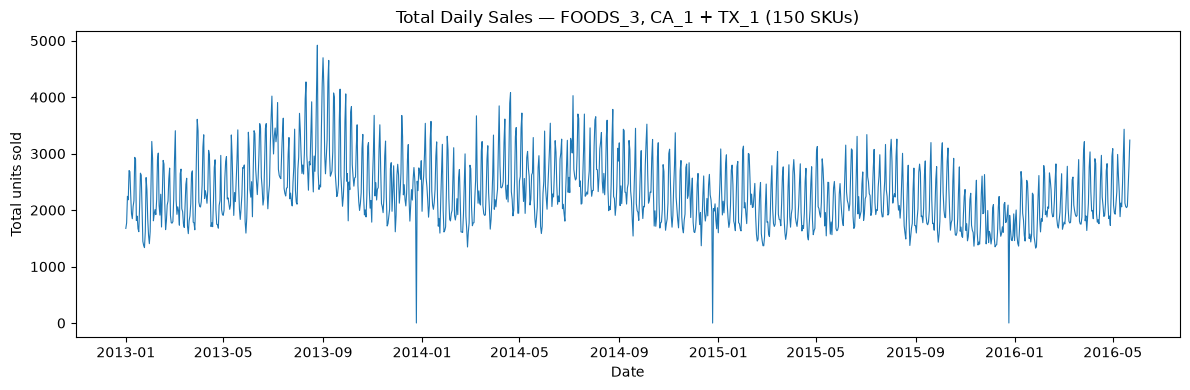

In [2]:
daily_total = df.groupby("date")["sales"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_total.index, daily_total.values, linewidth=0.8)
ax.set_title("Total Daily Sales — FOODS_3, CA_1 + TX_1 (150 SKUs)")
ax.set_xlabel("Date")
ax.set_ylabel("Total units sold")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_total_daily_sales.png", dpi=150)
plt.show()

**Takeaway:** Total daily demand is noisy but stable in level over the 3.4-year window, with a clear weekly cadence and a mild summer seasonal lift — no long-run trend or structural break that would require re-scoping the model window.

## 2. Day-of-week and monthly seasonality

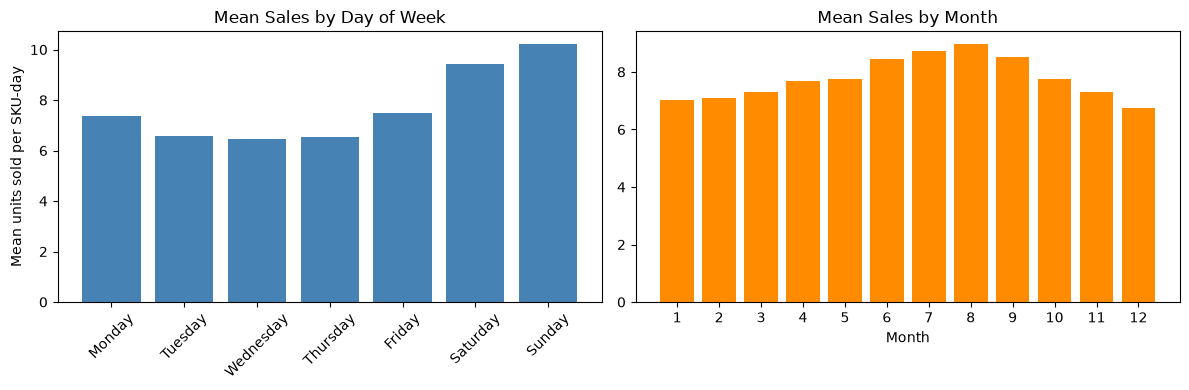

In [3]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_mean = df.groupby("weekday")["sales"].mean().reindex(dow_order)
month_mean = df.groupby("month")["sales"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(dow_mean.index, dow_mean.values, color="steelblue")
axes[0].set_title("Mean Sales by Day of Week")
axes[0].set_ylabel("Mean units sold per SKU-day")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(month_mean.index, month_mean.values, color="darkorange")
axes[1].set_title("Mean Sales by Month")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(1, 13))

fig.tight_layout()
fig.savefig(FIG_DIR / "02_seasonality.png", dpi=150)
plt.show()

**Takeaway:** Weekends dominate — Sunday averages 10.2 units/SKU-day vs. 6.5 on Wednesday, a ~58% swing — so day-of-week must be a core model feature; sales also step up in summer (Jun–Aug, ~8.4–9.0) and dip in Dec–Jan (~6.7–7.0).

## 3. Event/holiday effect

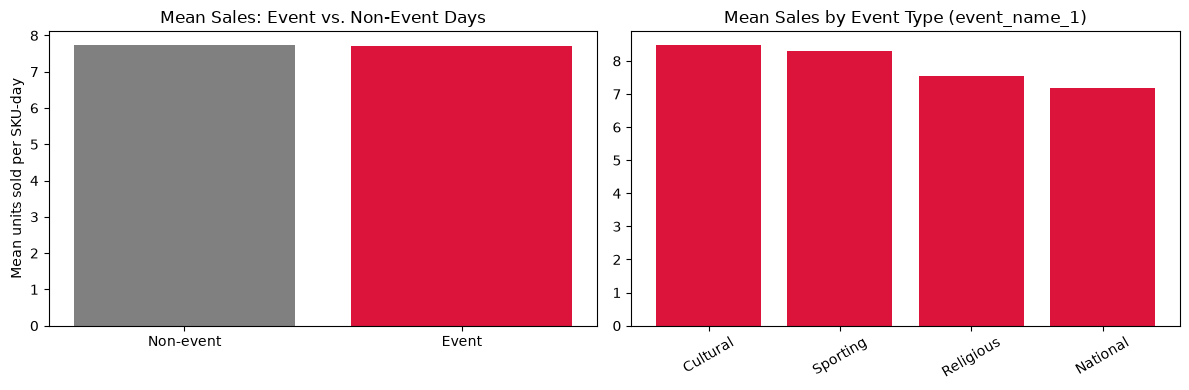

In [4]:
event_mean = df.groupby("is_event")["sales"].mean()
type_mean = df.groupby("event_type_1")["sales"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Non-event", "Event"], event_mean.values, color=["gray", "crimson"])
axes[0].set_title("Mean Sales: Event vs. Non-Event Days")
axes[0].set_ylabel("Mean units sold per SKU-day")

axes[1].bar(type_mean.index, type_mean.values, color="crimson")
axes[1].set_title("Mean Sales by Event Type (event_name_1)")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

**Takeaway:** The aggregate event-vs-non-event gap is essentially flat (7.71 vs. 7.73 mean units/SKU-day) because it nets out opposite effects — Cultural and Sporting events lift sales (~8.3–8.5) while National holidays suppress them (~7.2, e.g. stores closed or reduced traffic) — so event *type*, not a single event flag, should be the model feature.

## 4. SKU volatility: stable vs. volatile segments

Coefficient of variation (CV = std / mean) per store-item, computed over the full history. SKUs are split into **stable** (CV < median) and **volatile** (CV ≥ median). This mapping is saved and reused in `03_evaluation.ipynb` to break down forecast error by segment.

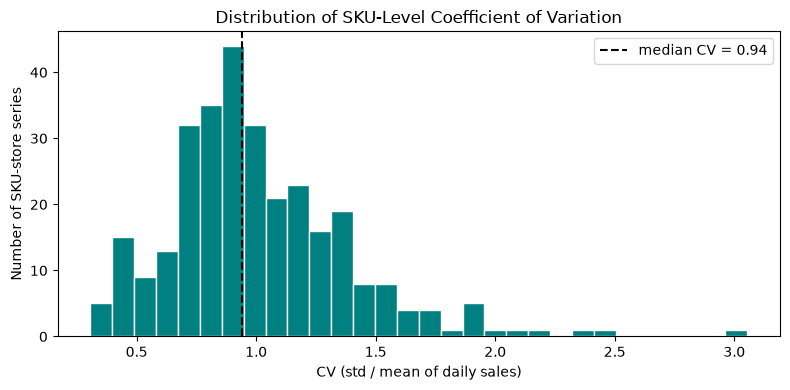

segment
volatile    150
stable      150
Name: count, dtype: int64
Saved segment mapping -> data/processed/sku_segments.parquet (300 rows)


In [5]:
sku_stats = df.groupby(["store_id", "item_id"])["sales"].agg(["mean", "std"]).reset_index()
sku_stats["cv"] = sku_stats["std"] / sku_stats["mean"]
median_cv = sku_stats["cv"].median()
sku_stats["segment"] = np.where(sku_stats["cv"] < median_cv, "stable", "volatile")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sku_stats["cv"], bins=30, color="teal", edgecolor="white")
ax.axvline(median_cv, color="black", linestyle="--", label=f"median CV = {median_cv:.2f}")
ax.set_title("Distribution of SKU-Level Coefficient of Variation")
ax.set_xlabel("CV (std / mean of daily sales)")
ax.set_ylabel("Number of SKU-store series")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03_sku_volatility_cv.png", dpi=150)
plt.show()

sku_stats.to_parquet("../data/processed/sku_segments.parquet", index=False)
print(sku_stats["segment"].value_counts())
print(f"Saved segment mapping -> data/processed/sku_segments.parquet ({len(sku_stats)} rows)")

**Takeaway:** CV ranges from 0.31 to 3.05 with a median of 0.94 — a roughly 10x spread in relative variability across SKUs — confirming that a single global model tolerance won't fit both ends; the stable/volatile split (150/150 by construction) is carried through to evaluation and safety-stock sizing.

## 5. Intermittency: zero-sales days per SKU

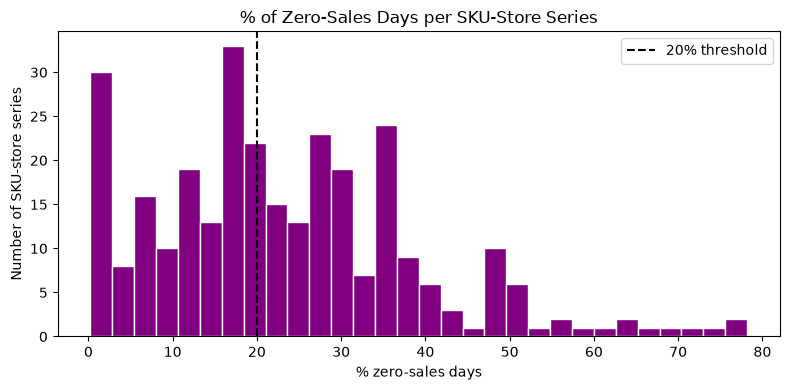

Mean zero-sales rate: 23.4% | median: 21.0%
SKUs with >20% zero-sales days: 162 / 300


In [6]:
zero_pct = df.groupby(["store_id", "item_id"])["sales"].apply(lambda s: (s == 0).mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(zero_pct * 100, bins=30, color="purple", edgecolor="white")
ax.axvline(20, color="black", linestyle="--", label="20% threshold")
ax.set_title("% of Zero-Sales Days per SKU-Store Series")
ax.set_xlabel("% zero-sales days")
ax.set_ylabel("Number of SKU-store series")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "04_intermittency.png", dpi=150)
plt.show()

print(f"Mean zero-sales rate: {zero_pct.mean():.1%} | median: {zero_pct.median():.1%}")
print(f"SKUs with >20% zero-sales days: {(zero_pct > 0.2).sum()} / {len(zero_pct)}")

**Takeaway:** 162 of 300 SKU-store series (54%) have more than 20% zero-sales days, and the average zero rate is 23% — a substantial share of demand is genuinely intermittent, which is exactly why WAPE (not a percentage-error metric like MAPE) is used as the primary evaluation metric.

## 6. Price effect: sales before/after price changes

For a few example SKUs with several price changes, compare the mean of the 7 days before vs. the 7 days after each change, split by whether the price went up or down.

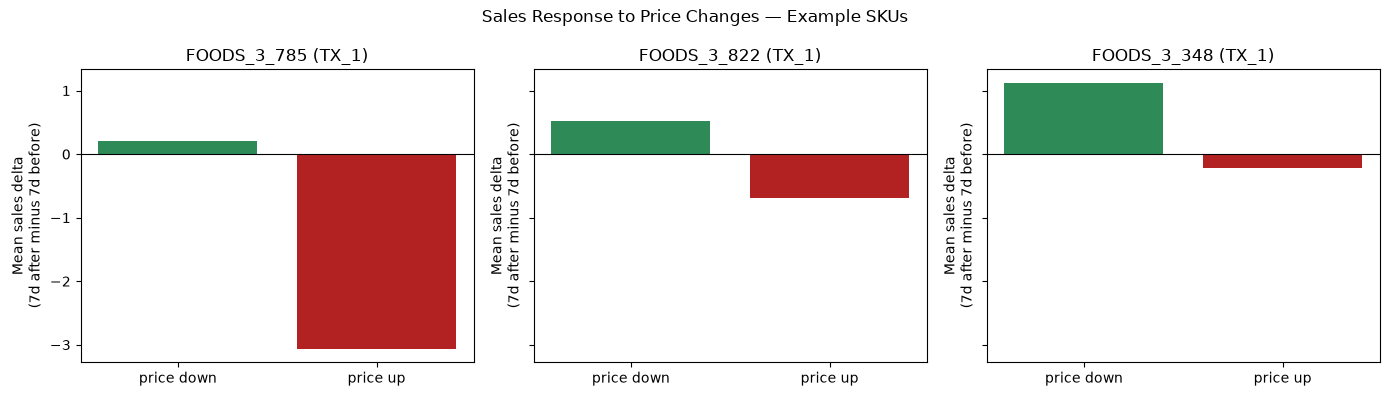

In [7]:
def price_change_deltas(sub, window=7):
    """Mean sales delta (after - before) around each price change, split by direction."""
    sub = sub.sort_values("date").reset_index(drop=True)
    change_idx = sub.index[sub["price_change_flag"]].tolist()
    rows = []
    for idx in change_idx:
        if idx >= window and idx + window <= len(sub):
            before = sub.loc[idx - window:idx - 1, "sales"].mean()
            after = sub.loc[idx:idx + window - 1, "sales"].mean()
            direction = "price up" if sub.loc[idx, "sell_price"] > sub.loc[idx - 1, "sell_price"] else "price down"
            rows.append({"direction": direction, "delta": after - before})
    return pd.DataFrame(rows)

example_skus = [("TX_1", "FOODS_3_785"), ("TX_1", "FOODS_3_822"), ("TX_1", "FOODS_3_348")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (store, item) in zip(axes, example_skus):
    sub = df[(df["store_id"] == store) & (df["item_id"] == item)]
    deltas = price_change_deltas(sub)
    summary = deltas.groupby("direction")["delta"].mean()
    bar_colors = ["seagreen" if v >= 0 else "firebrick" for v in summary.values]
    ax.bar(summary.index, summary.values, color=bar_colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{item} ({store})")
    ax.set_ylabel("Mean sales delta\n(7d after minus 7d before)")

fig.suptitle("Sales Response to Price Changes — Example SKUs")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_price_effect.png", dpi=150)
plt.show()

**Takeaway:** FOODS_3_785 shows clear price elasticity — sales drop by ~3.1 units/day on average after a price increase and rise slightly after a price cut — but the effect size varies a lot by SKU (FOODS_3_348 shows only a mild response), so price and a price-change flag are included as model features rather than assuming a uniform elasticity.

## Key EDA Findings

- **Weekly seasonality dominates**: Sunday sales average 10.2 units/SKU-day vs. 6.5 on Wednesday (~58% swing) — day-of-week is the single strongest calendar signal and must be a core feature.
- **Event effects are type-specific, not uniform**: the aggregate event-vs-non-event gap is flat, but Cultural/Sporting events lift sales (~8.3–8.5) while National holidays suppress them (~7.2) — a blanket "is_event" flag would wash out real, offsetting effects.
- **Demand is genuinely intermittent**: 54% of SKU-store series have >20% zero-sales days (mean 23%), which is why WAPE, a scale-aware metric robust to zero-heavy series, is used as the primary metric instead of MAPE.
- **SKU volatility spans a 10x range** (CV from 0.31 to 3.05, median 0.94) — the stable/volatile split built here carries through to model evaluation and safety-stock sizing, since a single accuracy target won't fit both groups.
- **Price elasticity exists but is SKU-specific**: some SKUs (e.g. FOODS_3_785) show a clear ~3 unit/day drop after a price increase, others barely react — price and price-change flags are included as features rather than a single global elasticity assumption.